# Comparación: Regresión Logística vs SVM vs KNN
**Dataset:** `Driver_Behavior.csv`



**Consejo:** **NO** escales antes de dividir en train/test. Primero split, luego fit del scaler solo con train.


### Objetivo
Construir y **comparar** tres modelos de clasificación (Logística, KNN y SVM) para predecir el comportamiento/riesgo del conductor.

### Bloques
- Bloque 1: Exploración
- Bloque 2: Preparación
- Bloque 3: Regresión logística
- Bloque 4: KNN
- Bloque 5: SVM
- Bloque 6: Comparación final

### Preguntas iniciales
1. ¿Por qué KNN es sensible al escalado?
- KNN es sensible al escalado ya que el modelo trabaja midiendo la distancias entre diferentes puntos, entonces si llegase a existir puntos que tienen mucha diferente, el modelo no lo cuadraría correctamente.
2. ¿Qué efecto tiene aumentar el parámetro C en SVM?
- Si aumentasemos de más, conseguiriamos que el modelo se adapte a los datos, lo que signficaria que hariamos overfitting, el modelo no sabría trabajar correctamente con datos nuevos.
3. ¿En qué se diferencia la frontera de decisión de Logística y SVM?

4. ¿Por qué la Accuracy puede no ser una buena métrica en problemas desbalanceados?
Porque si no esta balanceado, "tiraria" mucho hacia unos datos, se inclinaría para la categoria que mas datos tiene.



## Preparación
1. Coloca el archivo `Driver_Behavior.csv` en la **misma carpeta** que esté tu notebook, o ajusta la ruta.
2. Ejecuta celda a celda.
3. Mantén el notebook limpio: salidas relevantes, gráficos claros, comentarios breves.


In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt


In [26]:
# Carga del dataset
path = "Driver_Behavior.csv"
df = pd.read_csv(path)

display(df.head())
print("Shape:", df.shape)
df.info()


,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,Distracted
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,Distracted
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,Aggressive
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0,11.064505,0.539964,Aggressive
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1,21.967570,1.369908,Distracted


Shape: (30000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmph        30000 non-null  float64
 1   accel_x           30000 non-null  float64
 2   accel_y           30000 non-null  float64
 3   brake_pressure    30000 non-null  float64
 4   steering_angle    30000 non-null  float64
 5   throttle          30000 non-null  float64
 6   lane_deviation    30000 non-null  float64
 7   phone_usage       30000 non-null  int64  
 8   headway_distance  30000 non-null  float64
 9   reaction_time     30000 non-null  float64
 10  behavior_label    30000 non-null  object 
dtypes: float64(9), int64(1), object(1)
memory usage: 2.5+ MB



# Bloque 1 – Exploración

Completa:

1. Identifica **variable objetivo** (y) y **predictoras** (X).
2. Muestra:
   - `df.describe()` (si tiene sentido)
   - Recuento por clase de la variable objetivo
   - Valores nulos por columna
3. Responde (2–4 líneas cada una):
   - ¿Está balanceada la variable objetivo?
   - ¿Qué variables crees que pueden ser más predictoras?
   - ¿Conviene escalar? ¿Por qué?

💡 Consejo: si la variable objetivo está en texto (p.ej. "Safe"/"Aggressive"), necesitarás codificarla o usarla tal cual según scikit-learn (normalmente admite etiquetas tipo string).


In [27]:
df.describe()

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,59.986424,1.265818,0.368501,40.767624,-0.040207,55.001223,0.568549,0.333333,23.399177,0.999817
std,14.806008,1.026624,0.295654,26.721728,11.384086,21.475323,0.420563,0.471412,11.998469,0.466180
min,20.000000,-0.949617,-0.479718,0.003128,-59.989984,20.001444,0.000001,0.000000,5.004359,0.400008
25%,49.568893,0.506529,0.116047,18.722464,-6.215165,37.246356,0.234971,0.000000,13.683875,0.625024
50%,57.901281,0.831602,0.313145,39.951206,-0.018734,50.066483,0.456616,0.000000,20.133699,0.851295
75%,69.242746,1.968167,0.568768,57.914900,6.158074,70.144059,0.810950,1.000000,31.308284,1.396176
max,118.439831,5.308924,1.664605,99.994365,53.426806,99.994762,2.425784,1.000000,49.998924,1.999885


In [28]:
# Esta balanceado ya que todas las categorias tienen el mismo numero.
df.value_counts("behavior_label")

behavior_label
Aggressive    10000
Distracted    10000
Safe          10000
Name: count, dtype: int64

Las variables mas predictoras pueden ser speed_kmph, lane_deviation, phone_usage.
Conviene escalar, ya que observando un poco el dataset, hay campos que tienen numeros de valores muy diferentes entre si (puede haber un 50 y 0,1..)


# Bloque 2 – Preparación

1. Divide en train/test (80/20), con `random_state=42`.
2. Aplica **StandardScaler**:
   - `fit` SOLO con X_train
   - `transform` en X_train y X_test
3. Justifica por qué el escalado es importante para KNN y SVM.


In [29]:
X = df.drop(columns=["behavior_label"])
y = df["behavior_label"]

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Funciones de ayuda

- accuracy
- matriz de confusión
- classification_report
- ROC y AUC (si el modelo ofrece `predict_proba` o `decision_function`)



# Bloque 3 – Regresión Logística

1. Entrena una Regresión Logística.
2. Evalúa con:
   - Accuracy
   - Matriz de confusión
   - Classification report
   - ROC y AUC (si procede)
3. Interpreta:
   - ¿Qué tipo de error es más preocupante en este problema y por qué?


In [33]:
from sklearn import linear_model

logistica = linear_model.LogisticRegression()
logistica.fit(X_train_scaled, y_train)

y_pred = logistica.predict(X_test_scaled)


In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Matriz de confusión:
[[2000    0    0]
 [   0 2000    0]
 [   0    0 2000]]


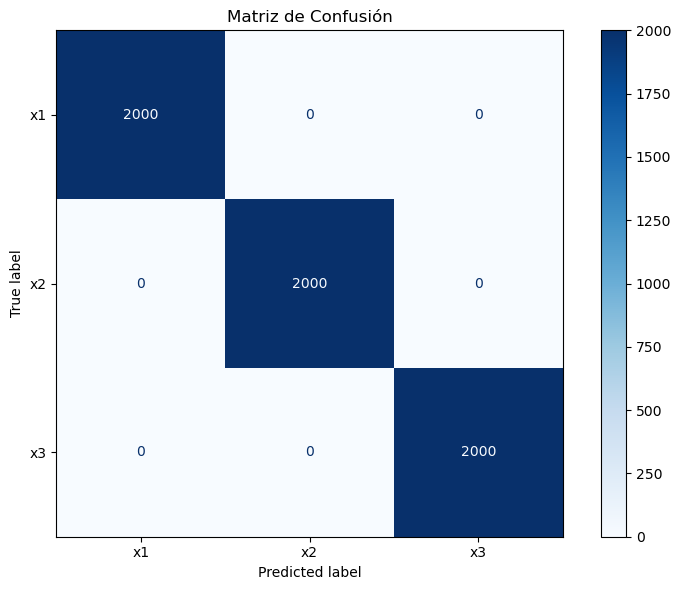

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2', 'x3'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      2000
  Distracted       1.00      1.00      1.00      2000
        Safe       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000




# Bloque 4 – KNN

1. Entrena KNN con `k=5`.
2. Evalúa con las mismas métricas.
3. Prueba al menos 3 valores distintos de k (por ejemplo: 1, 5, 11, 21).
4. Representa **Accuracy vs k** en un gráfico.
5. Elige el k "óptimo" y justifica tu elección.



# Bloque 5 – SVM

1. Entrena:
   - SVM lineal (`kernel="linear"`)
   - SVM RBF (`kernel="rbf"`)
2. Evalúa ambos modelos con las mismas métricas.
3. Modifica el parámetro **C** (por ejemplo: 0.1, 1, 10) y analiza el efecto.
4. Indica qué kernel funciona mejor y por qué.



# Bloque 6 – Comparación final

1. Crea una **tabla comparativa** con:
   - Accuracy
   - Recall (macro o de la clase positiva)
   - F1-score (macro o de la clase positiva)
   - AUC (si es binario)
2. Recomienda un modelo y justifica tu elección.

En problemas de seguridad, suele importar especialmente el **Recall** de la clase de riesgo.



# Preguntas

Responde brevemente:

1. ¿Por qué KNN es sensible al escalado?
2. ¿Qué efecto tiene aumentar el parámetro C en SVM?
3. ¿En qué se diferencia la frontera de decisión de Logística y SVM?
4. ¿Por qué la Accuracy puede no ser una buena métrica en problemas desbalanceados?


# Ayuda para las explicaciones
A la hora de responder a las preguntas, puedes ayudarte de esta pequeña guía.

1. Cada conclusión debe incluir:

    - Una métrica concreta
    - Una comparación explícita
    - Una consecuencia técnica


2. Siempre debes responder

    - ¿Qué significa esa métrica?
    - ¿Por qué importa aquí?
    - ¿Qué implicación tiene?

3. Cuando compares modelos debes responder a 3 preguntas (más o menos):
    - ¿Cuál rinde mejor globalmente? (Accuracy / AUC)
    - ¿Cuál detecta mejor la clase importante? (Recall)
    - ¿Cuál es más estable o generalizable?

>Estas notas son orientativas pero pueden ayudarte a la hora de mejorar tus respuestas.